In [1]:
import numpy as np
import torch

from tqdm.autonotebook import tqdm
from matplotlib import pyplot as plt

from place_cells import PlaceCells
from trajectory_generator import TrajectoryGenerator

from model import *

device = "cuda" if torch.cuda.is_available() else "cpu"

C:\Users\mufen\AppData\Local\Temp\ipykernel_32956\770337361.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Generate place cells

In [2]:
# Training options and hyperparameters
class Options:
    pass
options = Options()

# options.save_dir = '/mnt/fs2/bsorsch/grid_cells/models/'
options.n_steps = 100000      # number of training steps
options.batch_size = 200      # number of trajectories per batch
options.sequence_length = 20  # number of steps in trajectory
options.learning_rate = 1e-4  # gradient descent learning rate
options.Np = 1000              # number of place cells
options.Ng = 100             # number of grid cells
options.place_cell_rf = 0.12  # width of place cell center tuning curve (m)
options.surround_scale = 2    # if DoG, ratio of sigma2^2 to sigma1^2
options.RNN_type = 'RNN'      # RNN or LSTM
options.activation = 'relu'   # recurrent nonlinearity
options.weight_decay = 1e-4   # strength of weight decay on recurrent weights
options.DoG = True       # use difference of gaussians tuning curves
options.periodic = True      # trajectories with periodic boundary conditions
options.box_width = 1.6       # width of training environment
options.box_height = 1.6      # height of training environment
options.device = device       # specify devices

In [3]:
place_cells = PlaceCells(options)
trajectory_generator = TrajectoryGenerator(options, place_cells)

# Generate place cell centers, number controlled by res
# in total, res x res place cell centers
# returns: pc_outputs of shape [res x res, Np]

# Generate place cell centers, number controlled by res
# in total, res x res place cell centers
# returns: pc_outputs of shape [res x res, Np]

res = 30
pos = np.array(np.meshgrid(np.linspace(-options.box_width/2, options.box_width/2, res),
                         np.linspace(-options.box_height/2, options.box_height/2, res))).T
pos = torch.tensor(pos)
# pos = pos.reshape(-1, 2)

# # randomly sample from pos
# pos = pos[torch.randint(0, pos.shape[0], (900,))]
# pos = pos.reshape((30, 30, 2))
# Put on GPU if available
pos = pos.to(device)
print(pos.shape)

# in end, we have resxres tiled positions
# each center is represented by Np place cells
# in other words, each place cell will have firing rates across res x res centers
pc_outputs = place_cells.get_activation(pos).detach().cpu()
pc_outputs = pc_outputs.reshape(res * res, options.Np)
pc_outputs = pc_outputs - pc_outputs.mean(dim=0, keepdim=True)
print(pc_outputs.shape)

torch.Size([30, 30, 2])
torch.Size([900, 1000])


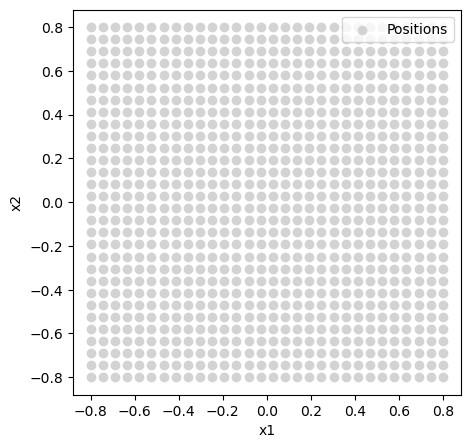

In [4]:
pos = pos.reshape((res**2, 2)).detach().cpu()
plt.figure(figsize=(5,5))
plt.scatter(pos[:,0], pos[:,1], c='lightgrey', label='Positions')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

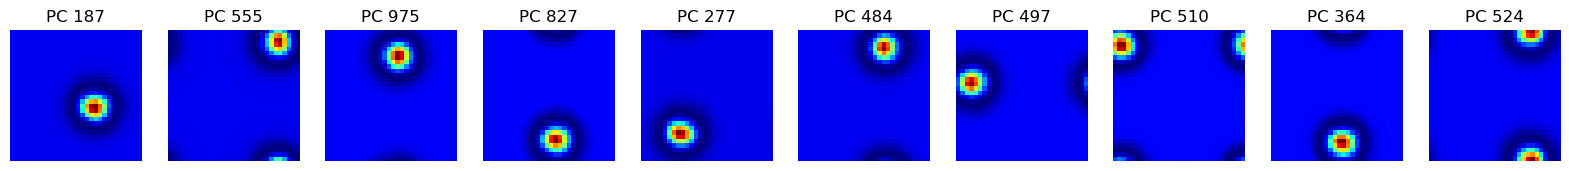

In [5]:
# randomly select some place cells to visualize
# essentially, we can think of these place fields as 'histograms' that approximates
# the real, continuous place fields
# res = 30
select = 10
pc_inds = np.random.choice(options.Np, size=select)
fig, ax = plt.subplots(1, 10, figsize=(20, 2))
for i in range(select):
    pc_i = pc_outputs[:, pc_inds[i]]
    ax[i].imshow(pc_i.reshape((res, res)), cmap='jet')
    ax[i].set_title(f'PC {pc_inds[i]}')
    ax[i].axis('off')
plt.show()


## PCN

In [7]:
nodes = [options.Ng, options.Np]
nonlin = 'Tanh'
inference_lr = 1e-2
inference_iters = 20
learning_lr = 2e-3
learning_iters = 600
batch_size = 100
sample_size = res ** 2
decay_step_size = 50
decay_rate = 0.5
lambda_W = 0.
lambda_hidden = 0.1

pcn = HierarchicalPCN(nodes, nonlin, lamb=lambda_hidden, use_bias=False).to(device)
X = torch.tensor(pc_outputs).to(device)
optimizer = torch.optim.Adam(pcn.parameters(), lr=learning_lr, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=decay_step_size, gamma=decay_rate)

train_mses = []
for i in range(learning_iters):
    iter_loss = 0
    for batch_idx in range(0, sample_size, batch_size):
        data = X[batch_idx:batch_idx+batch_size]
        optimizer.zero_grad()
        pcn.inference(data, inference_iters, inference_lr)
        l2_norm = torch.linalg.norm(pcn.layers[0].weight, 2)
        loss = pcn.get_energy()
        loss.backward()
        optimizer.step()

        iter_loss += loss.item() / (sample_size / batch_size)

        # progress_bar.set_postfix(loss=torch.mean(pcn.errs[-1]**2).item())
        # progress_bar.update(batch_size)
    if i % 10 == 0:
        print('Epoch', i)
        print('Loss', iter_loss)
        print('L2 norm', l2_norm.item())
    train_mse = iter_loss
    train_mses.append(train_mse)
    scheduler.step()

C:\Users\mufen\AppData\Local\Temp\ipykernel_32956\1850699393.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(pc_outputs).to(device)


Epoch 0
Loss 0.0808635014626715
L2 norm 1.8650000095367432
Epoch 10
Loss 0.07423391358719932
L2 norm 3.348284959793091
Epoch 20
Loss 0.06604628761609396
L2 norm 6.9743428230285645
Epoch 30
Loss 0.0573119612203704
L2 norm 8.330348014831543
Epoch 40
Loss 0.05116584772864978
L2 norm 8.917088508605957
Epoch 50
Loss 0.047467698239617884
L2 norm 9.210766792297363
Epoch 60
Loss 0.045482945111062795
L2 norm 9.311572074890137
Epoch 70
Loss 0.04399547932876481
L2 norm 9.383666038513184
Epoch 80
Loss 0.042760302623113
L2 norm 9.44311237335205
Epoch 90
Loss 0.04204542065660159
L2 norm 9.496548652648926
Epoch 100
Loss 0.04157294250196881
L2 norm 9.55262279510498
Epoch 110
Loss 0.043575534803999796
L2 norm 9.629451751708984
Epoch 120
Loss 0.04348759353160858
L2 norm 9.681560516357422
Epoch 130
Loss 0.04338573084937202
L2 norm 9.724310874938965
Epoch 140
Loss 0.043016892340448164
L2 norm 9.745661735534668
Epoch 150
Loss 0.04287455396519767
L2 norm 9.749093055725098
Epoch 160
Loss 0.0387755756576856
L

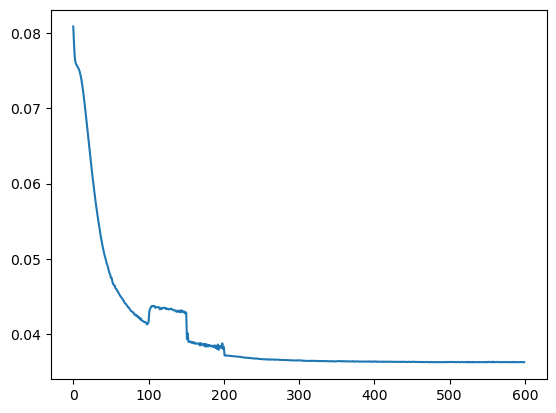

In [8]:
plt.figure()
plt.plot(train_mses)
plt.show()

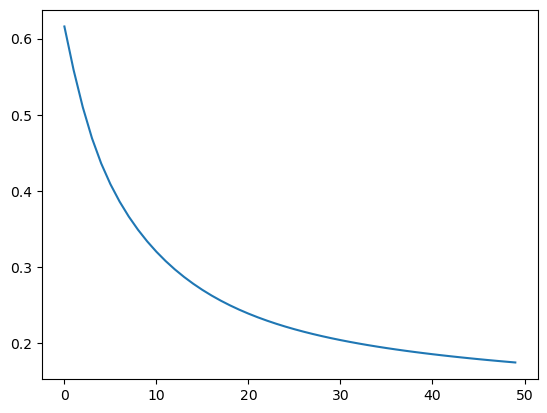

In [9]:
inference_iters = 50
inference_lr = 1e-3
pcn.lamb = 0.0
pcn.inference(X, inference_iters, inference_lr)
inference_energy = pcn.get_inf_losses()

plt.figure()
plt.plot(inference_energy)
plt.show()

(900, 100)


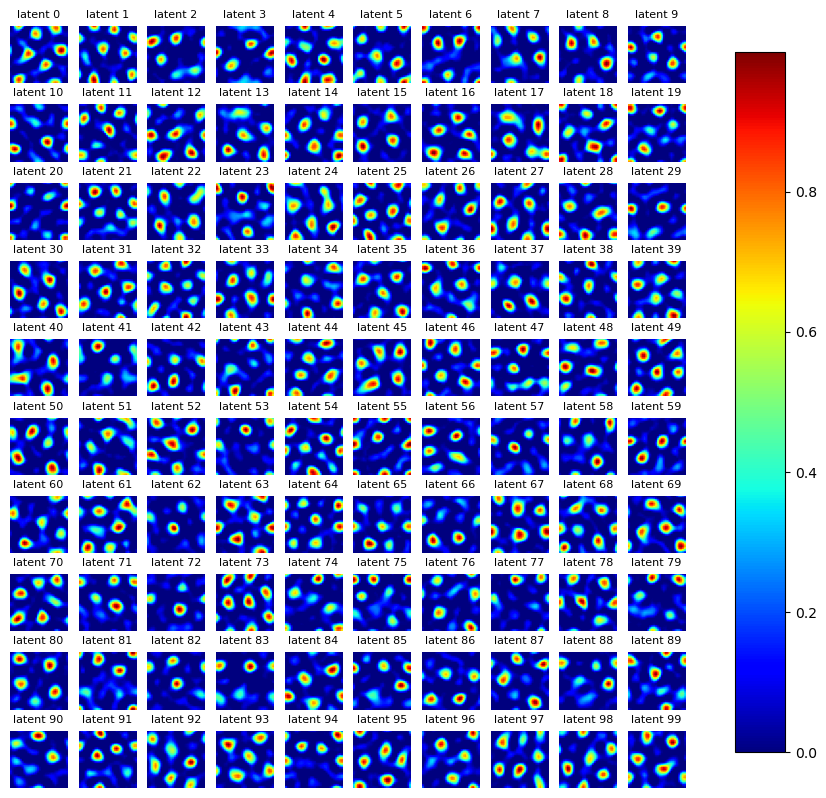

In [10]:
n_show = 10
gcs = pcn.val_nodes[0].detach().cpu().numpy()
# set seed
np.random.seed(0)
select = np.random.choice(gcs.shape[1], n_show**2, replace=False)
# sort the select
select = np.sort(select)
gcs = gcs[:, select]
print(gcs.shape)
fig, axes = plt.subplots(n_show, n_show, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    gc = gcs[:,i].real.reshape((res, res))
    gc = (gc - np.min(gc)) / (np.max(gc) - np.min(gc) + 1e-6)
    im = ax.imshow(gc, cmap='jet')
    ax.set_title(f'latent {select[i]}', fontsize=8)
    ax.axis('off')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

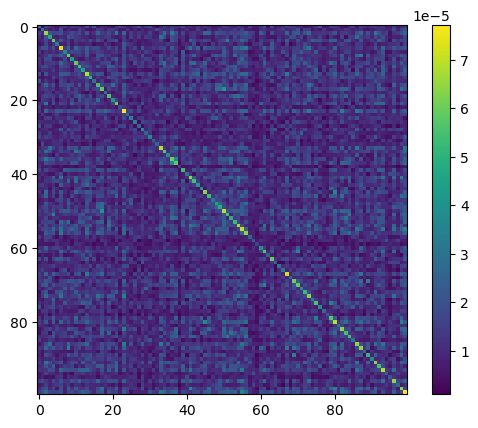

In [15]:
# examine whether the n_g by n_g matrix is orthogonal
g_cov = gcs.T @ gcs
plt.figure()
plt.imshow(g_cov)
plt.colorbar()
plt.show()

It looks as if PCN is developing some high resolution GCs than PCA

## Sparse coding

In [7]:
nodes = [options.Ng, options.Np]
nonlin = 'Tanh'
inference_lr = 1e-2
inference_iters = 20
learning_lr = 1e-3
learning_iters = 600
batch_size = 100
sample_size = res ** 2
lambda_z = 0.01
lambda_W = 0.
decay_step_size = 50
decay_rate = 0.5

# inference_lr = 1e-2
# inference_iters = 20
# learning_lr = 2e-3
# learning_iters = 600
# batch_size = 100
# sample_size = res ** 2
# decay_step_size = 50
# decay_rate = 0.5
# lambda_W = 0.

sparse_pcn = PredSparseCoding(options.Ng, options.Np, nonlin, lambda_z).to(device)
X = torch.tensor(pc_outputs).to(device)
optimizer = torch.optim.Adam(sparse_pcn.parameters(), lr=learning_lr, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=decay_step_size, gamma=decay_rate)

train_mses = []
for i in range(learning_iters):
    iter_loss = 0
    for batch_idx in range(0, sample_size, batch_size):
        data = X[batch_idx:batch_idx+batch_size]
        optimizer.zero_grad()
        sparse_pcn.inference(data, inference_iters, inference_lr)
        loss = sparse_pcn.get_energy(data)

        # add sparse constraint
        l1_norm = torch.linalg.norm(sparse_pcn.Wout.weight, 1)
        loss += lambda_W * l1_norm
        loss.backward()
        optimizer.step()

        # weight normalization - necessary for sparse coding!
        # sparse_pcn.weight_norm()

        iter_loss += loss.item() / (sample_size / batch_size)

    if i % 10 == 0:
        print('Epoch', i)
        print('Loss', iter_loss)
        print('Instant sparsity', l1_norm.item())
    train_mse = iter_loss
    train_mses.append(train_mse)
    scheduler.step()

C:\Users\mufen\AppData\Local\Temp\ipykernel_29036\1134746048.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(pc_outputs).to(device)


Epoch 0
Loss 171.24927944607208
Instant sparsity 48.18954849243164
Epoch 10
Loss 24.653821945190426
Instant sparsity 6.454159736633301
Epoch 20
Loss 12.155065218607586
Instant sparsity 0.11841684579849243
Epoch 30
Loss 12.131472163730196
Instant sparsity 0.11737589538097382
Epoch 40
Loss 12.108766131930881
Instant sparsity 0.13530106842517853
Epoch 50
Loss 12.090266863505045
Instant sparsity 0.13986575603485107
Epoch 60
Loss 12.130870713127983
Instant sparsity 0.1121385470032692
Epoch 70
Loss 12.159587860107422
Instant sparsity 0.11917465925216675
Epoch 80
Loss 12.126411543952095
Instant sparsity 0.11824831366539001
Epoch 90
Loss 12.160404629177517
Instant sparsity 0.12531715631484985
Epoch 100
Loss 12.124357435438368
Instant sparsity 0.12320324778556824
Epoch 110
Loss 12.128382152981228
Instant sparsity 0.10378614813089371
Epoch 120
Loss 12.092473771837023
Instant sparsity 0.10112937539815903
Epoch 130
Loss 12.134806527031792
Instant sparsity 0.10622652620077133
Epoch 140
Loss 12.1570

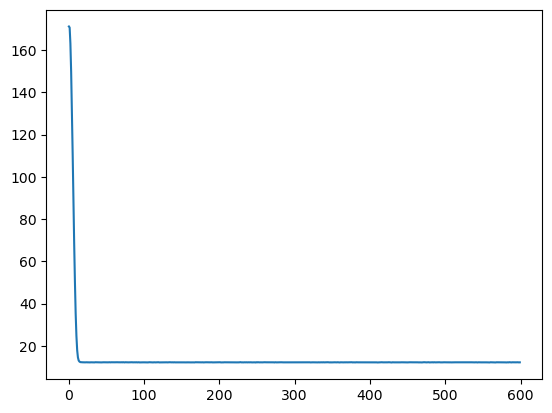

In [8]:
plt.figure()
plt.plot(train_mses)
plt.show()

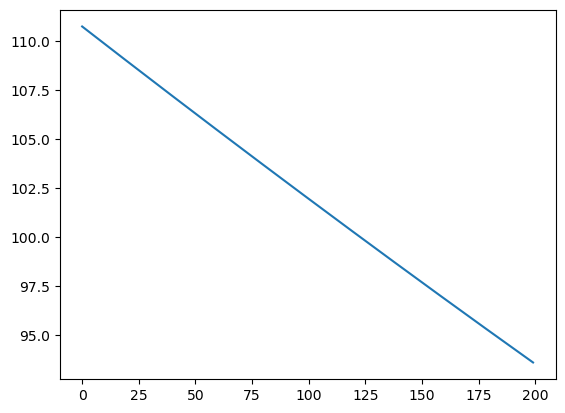

In [10]:

inference_lr = 1e-2
inference_iters = 200
sparse_pcn.inference(X, inference_iters, inference_lr)
inf_energy = sparse_pcn.get_inf_losses()

plt.figure()
plt.plot(inf_energy)
plt.show()

(900, 100)


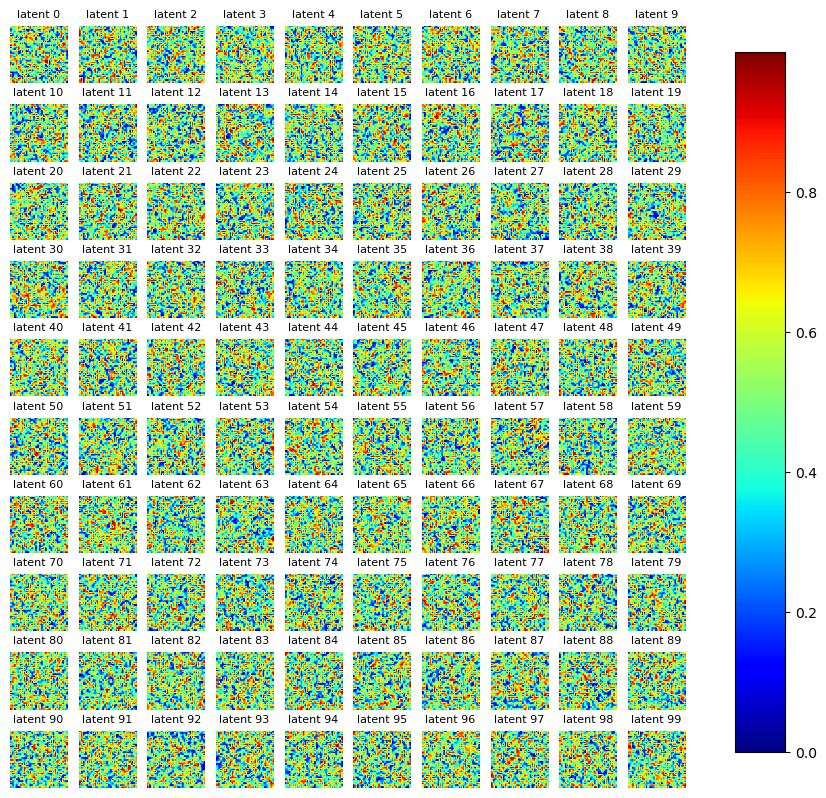

In [11]:
n_show = 10
gcs = sparse_pcn.get_hidden().detach().cpu().numpy()
# set seed
np.random.seed(0)
select = np.random.choice(gcs.shape[1], n_show**2, replace=False)
# sort the select
select = np.sort(select)
gcs = gcs[:, select]
print(gcs.shape)
fig, axes = plt.subplots(n_show, n_show, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    gc = gcs[:,i].real.reshape((res, res))
    gc = (gc - np.min(gc)) / (np.max(gc) - np.min(gc) + 1e-6)
    im = ax.imshow(gc, cmap='jet')
    ax.set_title(f'latent {select[i]}', fontsize=8)
    ax.axis('off')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

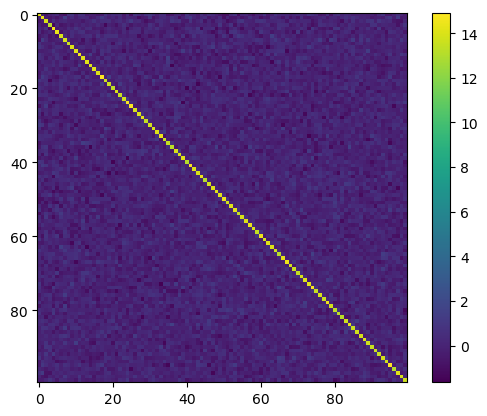

In [12]:
gc_cov = gcs.T @ gcs
plt.figure()
plt.imshow(gc_cov)
plt.colorbar()
plt.show()